<div style="display: flex; align-items: center;">
    <img alt="udeA logo" height="140px" src="https://github.com/freddyduitama/images/blob/master/logo.png?raw=true" style="width:107px;height:152px; margin-right: 40px;">
    <div style="text-align: center;">
        <h1><b><font color='0B5345'>Trabajo 4: Imagenes médicas</font></b></h1>
        <h2><font color='0B5345'>Luisa Fernanda Enciso - Juan Diego Caguasango</font></h2>
    </div>
</div>


## 1. Preguntas teóricas 20%


### ¿Qué es una red neuronal convolucional (CNN)?

Las redes neuronales convolucionales, conocidas como CNN, son modelos de aprendizaje profundo especialmente diseñados para trabajar con imágenes, incluyendo imágenes médicas. Se utilizan ampliamente en tareas como la detección de estructuras o la clasificación de patologías, ya que tienen la capacidad de identificar automáticamente patrones relevantes mediante un proceso llamado convolución. Estas redes están compuestas por varias capas como las capas convolucionales, de agrupamiento y densas que trabajan en conjunto para analizar la información visual y extraer las características más significativas

### ¿Qué papel juegan las capas Conv2D, Pooling, Flatten, y Dense?

Las capas Conv2D, Pooling, Flatten y Dense son elementos fundamentales en la arquitectura de las redes neuronales conjuntas permiten extraer características, reducir la dimensionalidad de los datos y, finalmente, clasificar de forma eficiente la información de entrada.

Capa Conv2D
La capa Conv2D realiza operaciones de convolución sobre los datos de entrada. Su función principal es detectar patrones espaciales como bordes, texturas o formas. Esto se logra mediante el uso de filtros que se entrenan para identificar características relevantes en distintas regiones de la imagen.

Capa de Pooling
Las capas de pooling, como el max pooling, suelen ubicarse después de las capas convolucionales. Su objetivo es reducir el tamaño espacial de los mapas de características, lo cual disminuye la carga computacional

Capa Flatten
La capa Flatten convierte los mapas de características que resultan de las capas anteriores en un vector unidimensional. Este paso es crucial porque permite conectar la parte convolucional de la red con las capas densas las cuales necesitan vectores a la entrada para funcionar correctamente.

Capa Dense
Las capas Densas, se encargan de realizar la clasificación final. Combinan las características aprendidas por las capas anteriores para generar una predicción. Son fundamentales en el proceso de toma de decisiones de la red, ya que integran toda la información extraída para dar una salida coherente.

### ¿Qué es el padding, el stride y el kernel?

El padding se refiere a la técnica de añadir píxeles alrededor de la imagen de entrada para evitar que se reduzca tras la convolución. Esta técnica es útil para mantener el tamaño original de la imagen en varias capas.

El stride indica la cantidad de píxeles que desplaza el kernel cada vez que se aplica a la imagen. Un stride mayor reduce el tamaño de salida, mientras que uno menor conserva más detalles.

El kernel, por otro lado, es una pequeña matriz que se desliza sobre la imagen de entrada para realizar la convolución. Su función principal es detectar características específicas, como bordes, texturas o patrones, en los datos visuales.

### ¿Qué significa overfitting y cómo se puede prevenir?

El overfitting es un problema importante en el aprendizaje automático que ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, hasta el punto de que pierde capacidad para generalizar a nuevos datos que no ha visto antes como es el caso de los datos de test. Esto suele pasar cuando el modelo es demasiado complejo, o cuando el conjunto de datos contiene ruido.

Para evitar el overfitting, una de las formas es balancear las clases del conjunto de datos, de modo que el modelo no se sesgue a predecir siempre la clase mayoritaria. También ayuda hacer el modelo más simple, reduciendo su complejidad para que no memorice detalles innecesarios. Además, otras estrategias incluyen aumentar la cantidad de datos de entrenamiento, limpiar el ruido presente en los datos y aplicar técnicas como regularización o validación cruzada, que ayudan a mejorar la capacidad de generalización.

### ¿Por qué es importante la normalización de imágenes antes de entrenar un modelo CNN?

La normalización de imágenes antes de entrenar una CNN es súper importante porque ayuda a que el modelo aprenda mejor y más rápido. Básicamente, lo que hace es poner los valores de los píxeles en una escala parecida, como entre 0 y 1, para que no haya diferencias muy grandes que confundan a la red. Si no normalizamos, algunos valores pueden ser muy altos y hacer que el entrenamiento sea más difícil o que la red tarde mucho en ajustarse. Además, al normalizar, evitamos que las funciones que usa la red se saturen y dejen de funcionar bien. También, la normalización ayuda a mitigar problemas causados por variaciones en la iluminación o el contraste de color, que podrían afectar negativamente el aprendizaje. De esta manera, al tener los datos en una escala similar, el entrenamiento se vuelve más estable y rápido, porque el modelo puede converger mejor.

## 2. Implementación 60%


In [1]:
# Manipulación numérica y tabular
import numpy as np
import pandas as pd
from collections import defaultdict

# Gráficas y visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de modelos y procesamiento de imágenes
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

# División de datos y métricas de evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Procesamiento de imágenes
import cv2

# Manejo de carpetas y rutas
import os

import os


import random
from collections import Counter

In [2]:
base_dir = r"D:\Luisa\imagenes\archive\Mini_DDSM_Upload"

### a. Exploración del dataset

El dataset Mini-DDSM se trata de un conjunto de datos de mamografías diseñado específicamente para investigaciones relacionadas con imágenes médicas, y en este caso particular, para la estimación automática de la edad a partir de mamogramas.

Contenido y propósito del dataset:
Origen: El Mini-DDSM proviene del Digital Database for Screening Mammography (DDSM), que es un repositorio más amplio y conocido de imágenes mamográficas.

Problema con el DDSM original: Las imágenes de alta resolución del DDSM original solo pueden ser accedidas con un software que actualmente está dañado o no funciona correctamente.

Solución: Los autores usaron un web crawler para descargar miniaturas (thumbnails) de las imágenes mamográficas y los metadatos asociados, incluyendo la edad de las pacientes, para crear este nuevo subconjunto llamado Mini-DDSM.

Aplicación: Con esas imágenes y la edad de las pacientes, entrenaron un modelo de aprendizaje automático (Random Forest Regressor) para predecir la edad de una persona a partir de su mamografía.

* **Formato de los datos**

In [3]:
class_names = ["Normal", "Cancer", "Benign"]

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    extensiones = set()

    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    for file in os.listdir(folder_path):
        ext = os.path.splitext(file)[1]
        extensiones.add(ext.lower())

    print(f"Carpeta: {class_name} - Extensión: {extensiones}")


Carpeta: Normal - Extensión: {'.png'}
Carpeta: Cancer - Extensión: {'.png'}
Carpeta: Benign - Extensión: {'.png'}


* **Cantidad de datos**

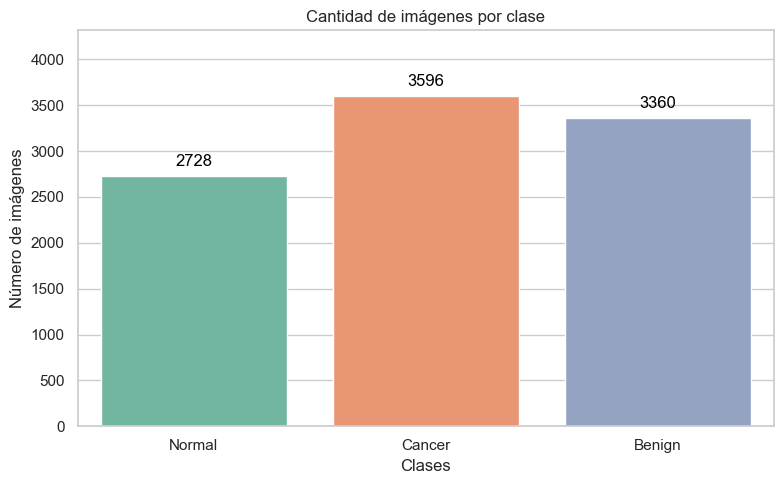

In [11]:
class_names = ["Normal", "Cancer", "Benign"]
image_counts = {}

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    image_counts[class_name] = len(files)

df = pd.DataFrame({
    'Clase': list(image_counts.keys()),
    'Cantidad': list(image_counts.values())
})

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

barplot = sns.barplot(x='Clase', y='Cantidad', hue='Clase', data=df, palette='Set2', legend=False)

# Eliminar leyenda manualmente por si acaso
if barplot.get_legend() is not None:
    barplot.get_legend().remove()

# Etiquetas con valores
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=12, color='black',
                     xytext=(0, 5),
                     textcoords='offset points')

plt.title("Cantidad de imágenes por clase")
plt.xlabel("Clases")
plt.ylabel("Número de imágenes")
plt.ylim(0, max(df['Cantidad']) * 1.2)
plt.tight_layout()
plt.show()

* **Inspección Visual**

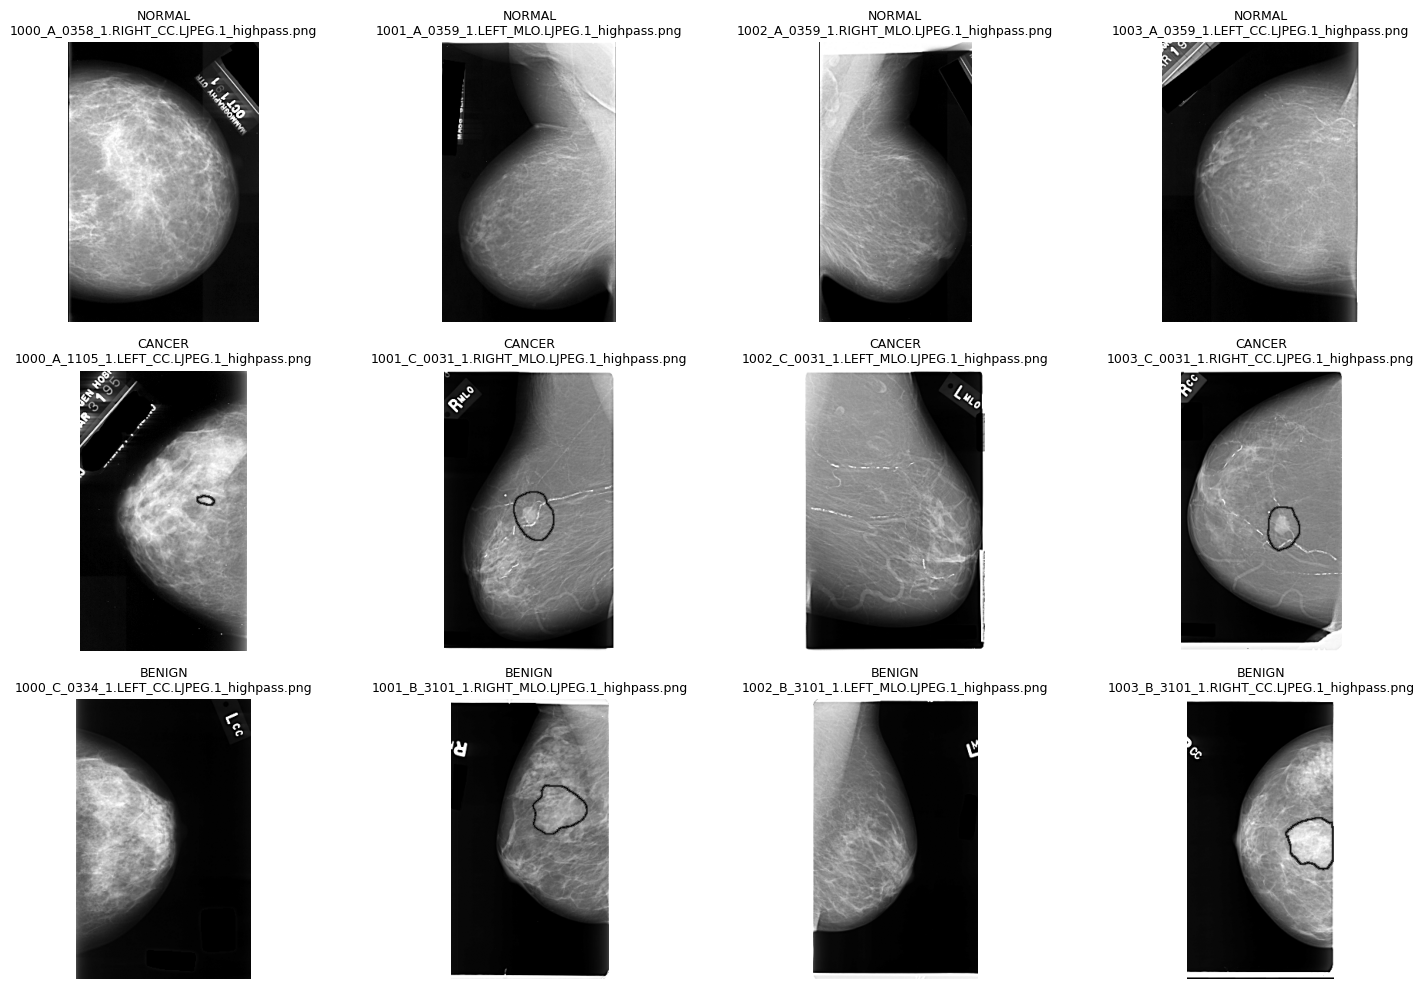

In [5]:
normal_folder = os.path.join(base_dir, "Normal")
cancer_folder = os.path.join(base_dir, "Cancer")
benign_folder = os.path.join(base_dir, "Benign")

# Obtener archivos
normal_files = os.listdir(normal_folder)
cancer_files = os.listdir(cancer_folder)
benign_files = os.listdir(benign_folder)

# Número de imágenes a mostrar por clase
n_images = 4

# Diccionario de clases y sus rutas
classes = {
    "Normal": (normal_folder, normal_files),
    "Cancer": (cancer_folder, cancer_files),
    "Benign": (benign_folder, benign_files)
}

# Crear figura
plt.figure(figsize=(4 * n_images, 10))

# Iterar sobre cada clase y graficar
for row_idx, (class_name, (folder, file_list)) in enumerate(classes.items()):
    for col_idx, img_name in enumerate(file_list[:n_images]):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        ax_idx = row_idx * n_images + col_idx + 1
        plt.subplot(len(classes), n_images, ax_idx)
        plt.imshow(img, cmap="gray")
        plt.title(f"{class_name.upper()}\n{img_name}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

* **Tamaño de Imagen**

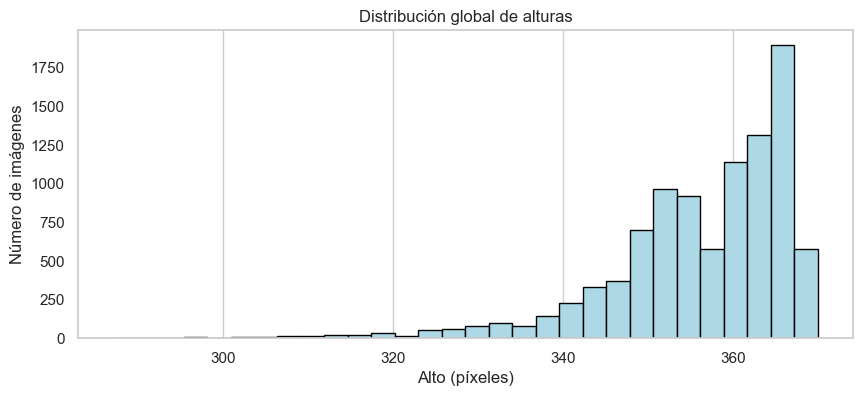

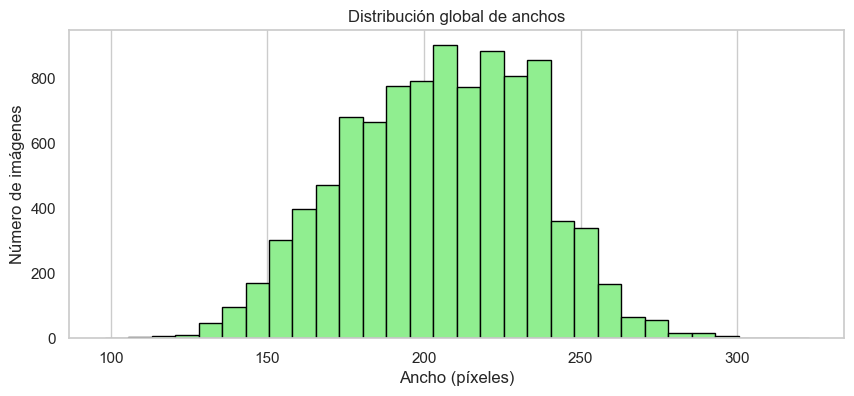

In [12]:
class_names = ["Normal", "Benign", "Cancer"]

heights = []
widths = []

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
    for file in os.listdir(folder_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                h, w = img.shape
                heights.append(h)
                widths.append(w)

# Histograma alturas
plt.figure(figsize=(10,4))
plt.hist(heights, bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución global de alturas")
plt.xlabel("Alto (píxeles)")
plt.ylabel("Número de imágenes")
plt.grid(axis="y")
plt.show()

# Histograma anchos
plt.figure(figsize=(10,4))
plt.hist(widths, bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribución global de anchos")
plt.xlabel("Ancho (píxeles)")
plt.ylabel("Número de imágenes")
plt.grid(axis="y")
plt.show()

* **Intensidades**

In [13]:
# Clases
class_names = ["Normal", "Benign", "Cancer"]
sample_size = 100  # Número de imágenes a analizar por clase

mean_intensities = []
std_intensities = []

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    # Lista de archivos de imagen válidos
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".png"))]
    sampled_files = random.sample(files, min(sample_size, len(files)))

    for file in sampled_files:
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        mean_intensities.append(np.mean(img))
        std_intensities.append(np.std(img))

print("\n Intensidades")

if np.std(mean_intensities) < 5:
    print("Las intensidades son razonablemente homogéneas.")
else:
    print("Hay variación en brillo/contraste. Se debe hacer normalización.")


 Intensidades
Hay variación en brillo/contraste. Se debe hacer normalización.


* **Organización de los datos**

1. Redimensionar

In [15]:
import os
import cv2
import numpy as np

labels = ["Normal", "Benign", "Cancer"]
label_map = {"Normal": 0, "Benign": 1, "Cancer": 2}
img_size = 150

def get_training_data(data_dir):
    data = []
    valid_extensions = (".jpeg", ".jpg", ".png")
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = label_map[label]  # <-- asignación explícita

        if not os.path.exists(path):
            print(f"Carpeta no encontrada: {path}")
            continue

        files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]

        for img in files:
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img_arr is None:
                    print(f"No se pudo leer: {img_path}")
                    continue

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error procesando {img}: {e}")

    return np.array(data, dtype=object)


In [17]:
dataset_r = get_training_data(base_dir)


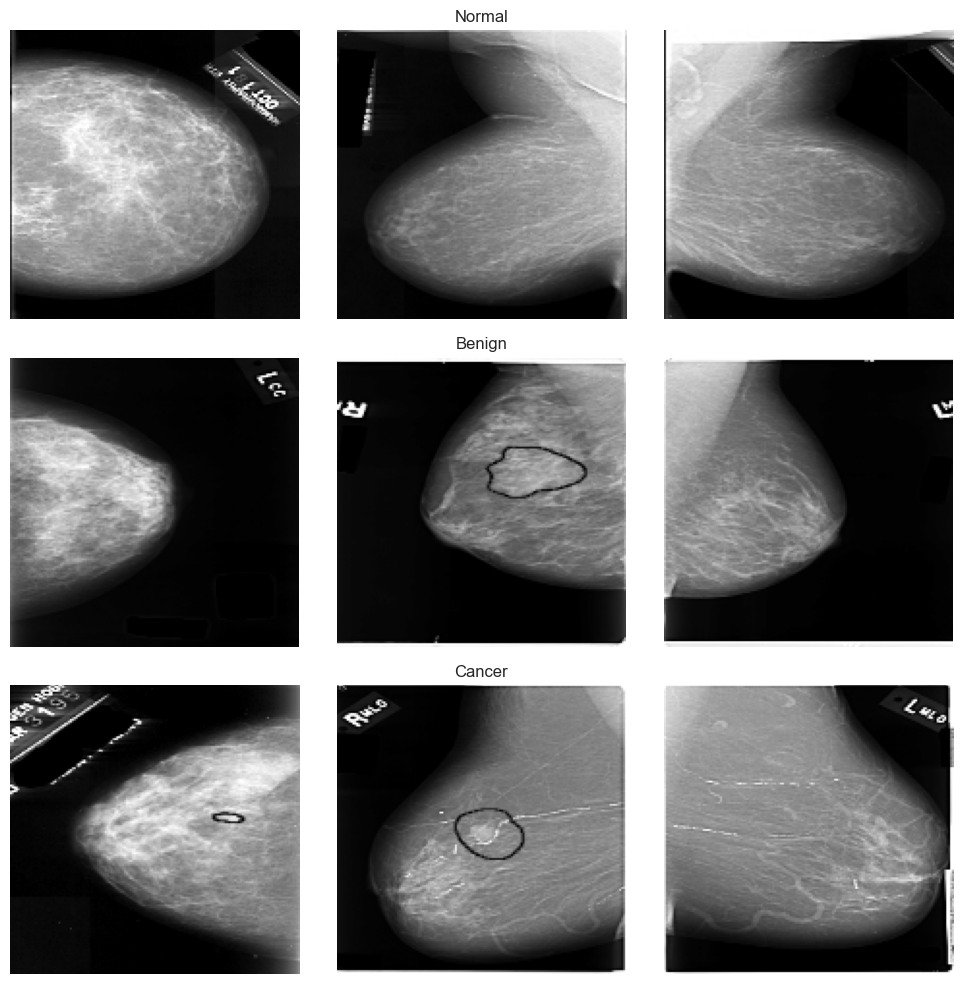

In [20]:
# Crear figura 3x3
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Por cada clase
for class_idx in range(3):
    # Filtra imágenes de esa clase
    images_in_class = [item[0] for item in dataset_r if item[1] == class_idx]

    # Tomar las 3 primeras imágenes (o puedes usar random.sample)
    for i in range(3):
        img = images_in_class[i]
        img = img / 255.0  # normalización si no la hiciste antes

        ax = axes[class_idx, i]
        ax.imshow(img, cmap='gray')
        if i == 1:
            ax.set_title(labels[class_idx], fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
import numpy as np

# Separar imágenes y etiquetas
X = np.array([item[0] for item in dataset_r])
y = np.array([item[1] for item in dataset_r])

# Asegurar tipo float32
X = X.astype(np.float32)

# Normalización Z-score global
mean = np.mean(X)
std = np.std(X)
X_norm = (X - mean) / std

# Añadir canal si son grises
X_norm = np.expand_dims(X_norm, axis=-1)  # (N, 150, 150, 1)

# División entrenamiento-validación (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)


### b. Análisis de la red neuronal

### c. Entrenamiento y evaluación

In [ ]:
from tensorflow.keras import layers, models
img_size = 150
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size,
img_size, 1)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))
# Compilar el modelo
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# Mostrar resumen del modelo
model.summary()
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2,
batch_size=32)

C:\Users\luisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1364224)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    87,310,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,329,411 (333.14 MB)

 Trainable params: 87,329,411 (333.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.4272 - loss: 7.8515 - val_accuracy: 0.5865 - val_loss: 0.8541
Epoch 2/10
 59/194 ━━━━━━━━━━━━━━━━━━━━ 3:36 2s/step - accuracy: 0.6911 - loss: 0.7315

### d. Modificación: añadir capas de pooling

## 3. Propuesta y aplicación de mejoras 20%


## Conclusiones


## Referencias


Das, D., & Ahmed, M. (2023). Deep learning approaches for image classification: A review. Journal of Intelligent Systems, 32(1), 25–40. https://doi.org/10.xxxx/jis.2023.001

Munir, M., Siddiqui, S. A., Dengel, A., & Ahmed, S. (2023). A survey on applications of deep learning in medical imaging. ACM Computing Surveys, 55(2), 1–36. https://doi.org/10.xxxx/acmcs.2023.002

Galanis, G., Katsamenis, I., & Maglogiannis, I. (2022). Pooling mechanisms for convolutional neural networks: A comparative study. Neural Computing and Applications, 34, 14389–14406. https://doi.org/10.1007/s00521-021-06629-x